# Генерация синтетических данных с использованием Faker

In [1]:
!pip install faker


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install faker

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import random
##библиотека, которая умеет генерировать реалистичные фейковые данные
from faker import Faker
##для работы с датами и временем.
from datetime import datetime, timedelta

In [5]:
# Инициализация генератора (русская локаль для реалистичных ФИО, адресов и т.д.)
fake = Faker('ru_RU')
Faker.seed(42)      # начальное число, с которого запускается генератор случайных чисел.
random.seed(42)

## Генерация синтетических данных для варианта "Сотрудники компании"

In [2]:
import pandas as pd
import random
from faker import Faker
from datetime import datetime, timedelta

fake = Faker('ru_RU')

# 1. ФУНКЦИЯ ДЛЯ ГЕНЕРАЦИИ ОТДЕЛОВ
def generate_departments(n):
    # Создаем пустой список, куда будем складывать словари с данными отделов
    departments = []
    
    # Запускаем цикл от 1 до n (включительно), чтобы создать n отделов
    for i in range(1, n + 1):
        # Добавляем (append) в наш список новый отдел в виде словаря
        departments.append({
            'department_id': i,                          # Порядковый номер (ID) отдела
            'name': fake.unique.job() + ' отдел',  # Берем уникальное случайное название профессии и добавляем слово "отдел" (напр., "Бухгалтер отдел")
            'location': fake.city()                     # Генерируем случайный российский город, где этот отдел находится
        })
        
    # Превращаем получившийся список словарей в красивую таблицу Pandas DataFrame и возвращаем её
    return pd.DataFrame(departments)


# 2. ФУНКЦИЯ ДЛЯ ГЕНЕРАЦИИ ДОЛЖНОСТЕЙ
def generate_positions(n: int) -> pd.DataFrame:
    # Создаем пустой список для хранения должностей
    positions = []
    
    # Цикл для генерации n штук должностей
    for i in range(1, n + 1):
        # Выбираем случайную минимальную зарплату для этой должности от 30 до 60 тысяч рублей
        min_salary = random.randint(30000, 60000)
        
        # Считаем максимальную зарплату: берем минимальную и прибавляем к ней случайный шаг от 20 до 80 тысяч
        max_salary = min_salary + random.randint(20000, 80000)
        
        # Добавляем сформированную должность в наш список
        positions.append({
            'position_id': i,              # Уникальный номер (ID) должности
            'name': fake.unique.job(),     # Генерируем уникальное название профессии (напр., "Программист")
            'min_salary': min_salary,      # Записываем вычисленный минимум
            'max_salary': max_salary       # Записываем вычисленный максимум
        })
        
    # Превращаем список должностей в таблицу Pandas DataFrame и возвращаем её
    return pd.DataFrame(positions)


# 3. ФУНКЦИЯ ДЛЯ ГЕНЕРАЦИИ СОТРУДНИКОВ
def generate_employees(n: int, department_ids: list, position_ids: list) -> pd.DataFrame:
    # Создаем пустой список для хранения данных всех сотрудников
    employees = []
    
    # Запускаем цикл, который сгенерирует нам n сотрудников. Переменная emp_id будет их номерами (от 1 до n)
    for emp_id in range(1, n + 1):        
        first_name = fake.first_name()   # Генерируем случайное имя
        last_name = fake.last_name()     # Генерируем случайную фамилию
        patronymic = fake.middle_name()  # Генерируем случайное отчество
        
        # Генерируем дату рождения человека, которому сейчас от 18 до 70 лет
        birth_date = fake.date_of_birth(minimum_age=18, maximum_age=70)
        
        phone = fake.phone_number()      # Генерируем случайный номер телефона в случайном формате
        email = fake.email()             # Генерируем фейковый электронный адрес
        
        # Генерируем адрес проживания и заменяем в нем переносы строк на запятые, чтобы всё было в одну строчку
        address = fake.address().replace('\n', ', ')
        
        # Вычисляем минимально возможную дату найма: дата рождения + 18 лет (чтобы не нанять несовершеннолетнего)
        min_hire_date = birth_date + timedelta(days=18*365)
        
        # Генерируем случайную дату найма на работу в промежутке между 18-летием и сегодняшним днем
        hire_date = fake.date_between(start_date=min_hire_date, end_date='today')
        
        # Выбираем статус сотрудника: 'active' (работает) или 'terminated' (уволен). 
        # Параметр weights задает шансы: 90% (0.9) что работает, и 10% (0.1) что уволен. [0] берет сам элемент из результата
        status = random.choices(['active', 'terminated'], weights=[0.9, 0.1])[0]
        
        # Случайным образом привязываем сотрудника к одному из существующих ID отделов, которые мы передали в функцию
        department_id = random.choice(department_ids)
        
        # Случайным образом привязываем сотрудника к одному из существующих ID должностей
        position_id = random.choice(position_ids)
        
        # Задаем сотруднику случайную текущую зарплату в диапазоне от 40 до 150 тысяч рублей
        salary = random.randint(40000, 150000)
        
        # Собираем все сгенерированные данные сотрудника в один большой словарь и добавляем в список
        employees.append({
            'employee_id': emp_id,
            'last_name': last_name,
            'first_name': first_name,
            'patronymic': patronymic,
            'birth_date': birth_date,
            'gender': random.choice(['М', 'Ж']), # Случайно выбираем пол
            'address': address,
            'phone': phone,
            'email': email,
            'hire_date': hire_date,
            'status': status,
            'department_id': department_id,
            'position_id': position_id,
            'salary': salary
        })
        
    # Превращаем заполненный список сотрудников в финальную таблицу Pandas DataFrame
    return pd.DataFrame(employees)


# 4. ФУНКЦИЯ ДЛЯ ИСТОРИИ ИЗМЕНЕНИЯ ЗАРПЛАТ
def generate_salary_history(employees_df: pd.DataFrame, avg_records: int = 3):    
    # Создаем пустой список для истории изменений
    history = []
    
    # Это будет сквозной счетчик (ID) для каждой строки в таблице истории
    record_id = 1
    
    # Проходимся циклом по каждой строчке (`iterrows`) готовой таблицы сотрудников
    for _, emp in employees_df.iterrows():
        emp_id = emp['employee_id']     # Вытаскиваем ID текущего сотрудника
        hire_date = emp['hire_date']     # Вытаскиваем его дату найма
        current_salary = emp['salary']  # Вытаскиваем его текущую (последнюю) зарплату
        
        # Решаем, сколько раз у этого сотрудника менялась зарплата за всё время.
        # Задаем вероятности: у 20% сотрудников не менялась (0), у 30% — 1 раз, у 30% — 2 раза, у 10% — 3 раза, у 10% — 4 раза
        num_changes = random.choices([0, 1, 2, 3, 4], weights=[0.2, 0.3, 0.3, 0.1, 0.1])[0]
        
        # Генерируем случайные даты изменений. Каждая дата — строго между днем найма сотрудника и сегодняшним днем.
        # Функция sorted() сортирует эти даты по порядку (от самых старых к самым свежим)
        change_dates = sorted([fake.date_between(start_date=hire_date, end_date='today') 
                               for _ in range(num_changes)])
        
        # ЛОГИКА 1: Если у сотрудника вообще не было изменений зарплаты (num_changes == 0)
        if num_changes == 0:
            # Мы всё равно должны добавить одну запись в историю — его стартовую зарплату в день найма
            history.append({
                'history_id': record_id,       # Номер записи
                'employee_id': emp_id,         # Кто этот сотрудник
                'change_date': hire_date,      # Дата изменения (в данном случае — день найма)
                'new_salary': current_salary   # Зарплата (его текущая)
            })
            record_id += 1 # Увеличиваем счетчик ID записей на 1 для следующего раза
            
        # ЛОГИКА 2: Если у сотрудника БЫЛИ изменения зарплаты (1, 2, 3 или 4 раза)
        else:
            # Генерируем прошлые зарплаты. Они должны быть меньше текущей. 
            # Создаем num_changes случайных чисел от 30 тыс. до текущей зарплаты и сортируем их по возрастанию (ведь карьеры обычно растут вверх)
            salary_values = sorted([random.randint(30000, current_salary) for _ in range(num_changes)])
            
            # В самый конец этого списка добавляем его текущую зарплату (ведь это финал его карьерного роста на данный момент)
            salary_values.append(current_salary)
            
            # Объединяем дату найма и сгенерированные даты изменений в один общий хронологический список дат
            all_dates = [hire_date] + change_dates
            
            # Теперь запускаем цикл по длине получившихся дат, чтобы связать каждую дату со своей зарплатой
            for i in range(len(all_dates)):
                # Добавляем строчку в историю
                history.append({
                    'history_id': record_id,
                    'employee_id': emp_id,
                    'change_date': all_dates[i],   # Берем i-ю дату из списка дат
                    'new_salary': salary_values[i] # Берем i-ю зарплату из списка зарплат
                })
                record_id += 1 # Увеличиваем ID записи истории
                
    # Превращаем весь получившийся лог изменений зарплат в таблицу Pandas DataFrame
    return pd.DataFrame(history)

In [3]:
N_DEPARTMENTS = 10 #10 уникальных отделов
N_POSITIONS = 20 #20 разных должностей
N_EMPLOYEES = 500 #500 сотрудников

In [4]:
# 1. Генерируем таблицу с отделами и сохраняем её в переменную departments_df
# Передаем константу N_DEPARTMENTS (число 10), чтобы функция создала ровно 10 отделов
departments_df = generate_departments(N_DEPARTMENTS)

# 2. Генерируем таблицу с должностями и сохраняем её в переменную positions_df
# Передаем константу N_POSITIONS (число 20), чтобы функция создала ровно 20 должностей
positions_df = generate_positions(N_POSITIONS)

# 3. Генерируем главную таблицу со всеми 500 сотрудниками
employees_df = generate_employees(
    N_EMPLOYEES,                               # Передаем число 500 — сколько сотрудников нужно создать
    departments_df['department_id'].tolist(),  # Берем колонку с ID всех отделов и превращаем в простой список [1, 2, 3...10], чтобы случайно распределять людей по отделам
    positions_df['position_id'].tolist()       # Берем колонку с ID всех должностей и тоже превращаем в список [1, 2, 3...20], чтобы выдавать людям случайные профессии
)

In [5]:
departments_df

,department_id,name,location
0,1,Эфферентолог отдел,к. Можга
1,2,Тестировщик отдел,к. Яшкуль
2,3,Портной отдел,клх Махачкала
3,4,Стоматолог отдел,с. Меренга
4,5,Коммерческий директор отдел,к. Усмань
5,6,Блоггер отдел,с. Курган
6,7,Фотомодель отдел,ст. Горно-Алтайск
7,8,Растениевод отдел,к. Ачинск
8,9,Онколог отдел,клх Дагомыс
9,10,Тренд-вотчер отдел,клх Красногорск (Моск.)


In [6]:
positions_df

,position_id,name,min_salary,max_salary
0,1,Продюсер,53147,97518
1,2,Товаровед,57893,88557
2,3,Терапевт,46759,84774
3,4,Нарколог,57976,105773
4,5,Эколог,59702,134738
5,6,Геодезист,32373,97612
6,7,Борт-стрелок,40076,88669
7,8,Страховой агент,59260,83993
8,9,Декоратор,49930,128199
9,10,Педиатр,51874,95507


In [10]:
employees_df

,employee_id,last_name,first_name,patronymic,birth_date,gender,address,phone,email,hire_date,status,department_id,position_id,salary
0,1,Гаврилов,Мина,Кузьминична,1973-08-07,М,"к. Бологое, пер. Островского, д. 77, 242388",+7 928 327 64 83,tatjana_03@example.org,2009-06-19,active,7,11,76421
1,2,Григорьева,Ольга,Федотович,1995-02-21,Ж,"д. Красногорск (Моск.), ш. Заречное, д. 684 ст...",8 532 871 01 22,erjabova@example.com,2023-10-07,active,6,4,52156
2,3,Крюкова,Лаврентий,Егоровна,1989-12-24,М,"п. Хасавюрт, ул. Вахитова, д. 382, 824896",83252880957,makarovamaja@example.com,2015-03-05,active,6,20,74671
3,4,Лукина,Тимур,Николаевна,2002-05-18,М,"г. Яхрома, алл. Профсоюзная, д. 951, 473829",+7 (465) 787-1331,adrian_98@example.org,2025-04-07,active,9,4,89615
4,5,Мартынов,Савватий,Станиславовна,1987-08-14,М,"п. Уварово, алл. Челюскинцев, д. 84 к. 81, 080132",8 311 656 67 01,maslovalukija@example.org,2019-06-07,active,10,12,115674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,Кузнецова,Твердислав,Теймуразович,1992-04-24,Ж,"с. Кажим, бул. Ручейный, д. 1 стр. 1, 669579",+7 (996) 872-25-89,semendementev@example.org,2010-12-14,active,4,16,112173
496,497,Фомина,Амвросий,Валерьевич,1966-11-10,М,"клх Котельнич, алл. Угольная, д. 4/4 стр. 356,...",+78255442867,ikarpov@example.com,1996-12-13,active,8,16,100401
497,498,Гуляев,Мефодий,Владленович,1994-08-04,Ж,"к. Ардон, пр. Механический, д. 9/6 стр. 895, 4...",+7 (693) 358-95-13,vatslav_2008@example.net,2014-08-14,active,6,6,58344
498,499,Корнилова,Евдокия,Якубович,1994-09-11,М,"п. Партизанск, ул. 40 лет Победы, д. 8 к. 455,...",+7 179 720 38 59,karpevseev@example.org,2020-10-10,active,9,2,108674


In [8]:
# Генерация истории зарплат
salary_history_df = generate_salary_history(employees_df, avg_records=3)
salary_history_df

#Его наняли 24 мая 2012 года на зарплату 37 375 ₽.
#Всего через 4 месяца (21 сентября 2012) ему подняли зарплату до 58 539 ₽.
#Потом подняли еще раз в ноябре 2012, затем в 2021 году, и его текущая зарплата в сентябре 2024 года составила 113 327 ₽.

,history_id,employee_id,change_date,new_salary
0,1,1,2012-05-24,84296
1,2,1,2013-12-24,113327
2,3,2,2007-09-10,38717
3,4,2,2007-12-25,41652
4,5,2,2009-04-02,56066
...,...,...,...,...
1290,1291,499,2023-09-10,91291
1291,1292,499,2024-06-28,115790
1292,1293,499,2025-10-28,116572
1293,1294,500,2005-11-20,41783


In [14]:
# Сохранение в CSV
departments_df.to_csv('departments.csv', index=False)
positions_df.to_csv('positions.csv', index=False)
employees_df.to_csv('employees.csv', index=False)
salary_history_df.to_csv('salary_history.csv', index=False)

# Задание на самостоятельную работу
Создать синтетический набор данных, сохранить его в csv файлы, построить на основе данных онтологию, вывести онтограф.


### Вариант 5. Интернет-магазин: товары, заказы, покупатели
Сущности:
- Покупатель: id, email, ФИО, телефон, дата регистрации.
- Товар: id, название, категория, цена, остаток на складе.
- Заказ: id, id покупателя, дата, статус (новый, оплачен, отгружен, доставлен).
- Состав заказа: id заказа, id товара, количество, цена в момент заказа.
- Отзыв: id, id покупателя, id товара, оценка (1–5), текст, дата.

Объём: 500 покупателей, 1000 товаров, 3000 заказов (в среднем по 2 товара в заказе), 1500 отзывов.

Онтология:
- Классы: Покупатель, Товар, Заказ, СтрокаЗаказа, Отзыв.
- Связи: покупатель делает заказ, заказ содержит товары (с количеством), покупатель оставляет отзыв на товар.

In [16]:
## Шаг 1. Установка библиотек и генерация данных в CSV

In [1]:
%pip install faker pandas

# Импортируем библиотеку pandas для работы с таблицами и сохранения их в CSV
import pandas as pd
# Импортируем встроенный модуль random для случайного выбора и генерации чисел
import random
# Импортируем класс Faker для создания реалистичных имен, дат и почтовых адресов
from faker import Faker

# Создаем генератор фейковых данных с русскими именами, названиями и городами
fake = Faker('ru_RU')
# Фиксируем сид для Faker, чтобы при каждом запуске имена и даты генерировались одинаково
Faker.seed(42)
# Фиксируем сид для random, чтобы случайные числа (цены, ID, статусы) тоже были постоянными
random.seed(42)

# Прописываем константы строго по условию Варианта №5 вашего ИДЗ
N_CUSTOMERS = 500  # Нам нужно сгенерировать 500 покупателей
N_PRODUCTS = 1000  # Нужно сгенерировать 1000 товаров
N_ORDERS = 3000    # Нужно сгенерировать 3000 заказов
N_REVIEWS = 1500   # Нужно сгенерировать 1500 отзывов

# Печатаем в консоль техническое уведомление, что процесс пошел
print("Генерация данных запущена...")


# 1. СИНТЕЗ ПОКУПАТЕЛЕЙ
# Создаем пустой список для хранения данных о покупателях
customers = []
# Запускаем цикл от 1 до 500, чтобы сгенерировать каждого покупателя отдельно
for i in range(1, N_CUSTOMERS + 1):
    # Добавляем в список словарь со свойствами одного покупателя
    customers.append({
        'customer_id': i,                 # Порядковый уникальный номер покупателя (ID)
        'email': fake.unique.email(),     # Генерируем уникальный адрес электронной почты
        'full_name': fake.name(),         # Генерируем полноценное русское ФИО
        'phone': fake.phone_number(),     # Генерируем случайный номер телефона
        # Выбираем дату регистрации за последние 3 года (от -3 лет до сегодняшнего дня)
        'reg_date': fake.date_between(start_date='-3y', end_date='today')
    })
# Превращаем получившийся список словарей в полноценную таблицу Pandas DataFrame
customers_df = pd.DataFrame(customers)


# 2. СИНТЕЗ ТОВАРОВ
# Задаем списки реальных товаров для каждой категории
products_pool = {
    'Электроника': ['Смартфон', 'Ноутбук', 'Беспроводные наушники', 'Умные часы', 'Планшет', 'Телевизор', 'Портативная колонка', 'Пауэрбанк', 'Игровая приставка', 'Монитор'],
    'Одежда': ['Футболка хлопковая', 'Джинсы классические', 'Худи оверсайз', 'Куртка демисезонная', 'Спортивный костюм', 'Кроссовки', 'Носки (набор)', 'Рубашка', 'Платье', 'Свитер'],
    'Книги': ['Художественный роман', 'Детектив', 'Фантастика', 'Бизнес-литература', 'Психология и саморазвитие', 'Учебник по программированию', 'Комикс / Манга', 'Историческая книга', 'Детская сказка', 'Поэтический сборник'],
    'Дом': ['Постельное белье', 'Набор посуды', 'Одеяло пуховое', 'Ортопедическая подушка', 'Светодиодная лампа', 'Робот-пылесос', 'Термокружка', 'Настенные часы', 'Шторы blackout', 'Коврик для ванной'],
    'Спорт': ['Коврик для йоги', 'Спортивная бутылка', 'Гантели наборные', 'Фитнес-резинки', 'Эспандер', 'Рюкзак спортивный', 'Велосипедный шлем', 'Скакалка с счетчиком', 'Спортивные перчатки', 'Напульсники']
}

# Извлекаем список категорий из ключей словаря
categories = list(products_pool.keys())
products = []

# Запускаем цикл от 1 до 1000
for i in range(1, N_PRODUCTS + 1):
    # Случайно выбираем категорию
    cat = random.choice(categories)
    # Случайно выбираем базовое название товара из этой категории
    base_name = random.choice(products_pool[cat])
    
    # Добавляем в список сформированный товар
    products.append({
        'product_id': i,
        # Формируем красивое название, например: "Смартфон #432" или "Худи оверсайз #105"
        'name': f"{base_name} #{random.randint(100, 999)}",
        'category': cat,
        # Генерируем цену от 300 до 50000 рублей и округляем до 2 знаков
        'price': round(random.uniform(300, 50000), 2),
        # Задаем остаток товара на складе (от 0 до 100 штук)
        'stock': random.randint(0, 100)
    })

# Переводим список товаров в таблицу Pandas DataFrame
products_df = pd.DataFrame(products)


# 3. СИНТЕЗ ЗАКАЗОВ И ИХ СОСТАВА (СТРОК)
# Создаем пустой список для общей информации о заказах (кто заказал, когда и какой статус)
orders = []
# Создаем пустой список для внутренностей заказов (какие товары лежат внутри каждого заказа)
order_items = []
# Заводим счетчик для уникальных ID строк состава заказа
item_id_counter = 1

# Вытаскиваем список всех ID покупателей, чтобы связывать заказы с реальными людьми
customer_ids = customers_df['customer_id'].tolist()
# Делаем  словарь, где ключ — это ID товара, а значение — его базовая цена (нужно, чтобы быстро узнавать цену товара)
product_dict = products_df.set_index('product_id')['price'].to_dict() #set_index- строка это айди, значение - имя
# Вытаскиваем список всех доступных ID товаров из ключей словаря
product_ids = list(product_dict.keys())
# Прописываем возможные этапы (статусы) обработки заказа
statuses = ['новый', 'оплачен', 'отгружен', 'доставлен']

# Запускаем цикл от 1 до 3000, чтобы сгенерировать 3000 уникальных заказов
for order_id in range(1, N_ORDERS + 1):
    # Выбираем случайного покупателя, который совершит этот заказ
    cust_id = random.choice(customer_ids)
    # Находим дату регистрации этого конкретного покупателя (заказ нельзя сделать РАНЬШЕ, чем покупатель зарегистрировался!)
    cust_reg_date = customers_df.loc[customers_df['customer_id'] == cust_id, 'reg_date'].values[0]
    # Генерируем дату заказа в промежутке между регистрацией этого клиента и сегодняшним днем
    order_date = fake.date_between(start_date=cust_reg_date, end_date='today')
    
    # Добавляем "шапку" заказа в список заказов
    orders.append({
        'order_id': order_id,       # ID заказа
        'customer_id': cust_id,     # ID покупателя, который его сделал
        'order_date': order_date,   # Дата оформления
        # Выбираем статус. Параметр weights задает реалистичность: 50% заказов уже доставлены (0.5), а новых всего 10% (0.1)
        'status': random.choices(statuses, weights=[0.1, 0.2, 0.2, 0.5])[0]
    })
    
    # Имитируем условие задания: в среднем по 2 товара в заказе. 
    # Задаем случайное количество позиций (от 1 до 3) с уклоном на то, что чаще всего выпадает именно 2 товара (вес 0.5)
    n_items = random.choices([1, 2, 3], weights=[0.3, 0.5, 0.2])[0]
    # Выбираем n_items СЛУЧАЙНЫХ и УНИКАЛЬНЫХ товаров из списка, чтобы внутри одного заказа позиции не дублировались
    chosen_prods = random.sample(product_ids, n_items)
    
    # Проходимся по каждому выбранному для этого заказа товару
    for prod_id in chosen_prods:
        # Добавляем строчку в состав (детализацию) текущего заказа
        order_items.append({
            'order_id': order_id,                # К какому заказу относится строка
            'product_id': prod_id,               # Какой именно товар купили
            'quantity': random.randint(1, 3),    # Сколько штук купили (случайно от 1 до 3 единиц)
            'price_at_order': product_dict[prod_id] # Фиксируем цену товара на момент покупки (берем её из нашего словаря цен)
        })
        # Увеличиваем счетчик строк
        item_id_counter += 1

# Превращаем накопленные данные по заказам и их составам в таблицы DataFrame
orders_df = pd.DataFrame(orders)
order_items_df = pd.DataFrame(order_items)

# 4. СИНТЕЗ ОТЗЫВОВ
# Создаем пустой список для отзывов
reviews = []
# Создаем текстовые шаблоны для отзывов в зависимости от поставленной оценки (от 1 до 5 звезд)
review_texts = {
    1: "Ужасно, пришло сломанным.", 2: "Качество не очень.", 
    3: "Нормально, сойдет.", 4: "Хороший товар, рекомендую.", 
    5: "Отлично! Всё супер."
}
# Запускаем цикл от 1 до 1500 для генерации отзывов
for i in range(1, N_REVIEWS + 1):
    # Выбираем оценку от 1 до 5. Веса настроены так, что хороших отзывов (4 и 5) гораздо больше (суммарно 80%)
    rating = random.choices([1, 2, 3, 4, 5], weights=[0.05, 0.05, 0.1, 0.3, 0.5])[0]
    # Добавляем сформированный отзыв в список
    reviews.append({
        'review_id': i,                        # Уникальный номер (ID) самого отзыва
        'customer_id': random.choice(customer_ids), # Выбираем случайного покупателя, кто написал отзыв
        'product_id': random.choice(product_ids),   # Выбираем случайный товар, на который написан отзыв
        'rating': rating,                      # Присваиваем сгенерированную оценку
        'text': review_texts[rating],          # Достаем текст, соответствующий этой оценке из словаря шаблонов
        # Генерируем дату отзыва за последние 2 года
        'review_date': fake.date_between(start_date='-2y', end_date='today')
    })
# Превращаем список отзывов в финальную таблицу Pandas DataFrame
reviews_df = pd.DataFrame(reviews)


# Сохраняем каждую из 5 созданных таблиц в одноименный файл формата .csv.
# Параметр index=False отключает сохранение системной колонки с номерами строк Pandas, чтобы файлы были чистыми.
customers_df.to_csv('customers.csv', index=False)
products_df.to_csv('products.csv', index=False)
orders_df.to_csv('orders.csv', index=False)
order_items_df.to_csv('order_items.csv', index=False)
reviews_df.to_csv('reviews.csv', index=False)

print(f"Готово! Созданы файлы: \n- покупатели ({len(customers_df)}) \n- товары ({len(products_df)}) \n- заказы ({len(orders_df)}) \n- строки заказов ({len(order_items_df)}) \n- отзывы ({len(reviews_df)})")

Note: you may need to restart the kernel to use updated packages.
Генерация данных запущена...
Готово! Созданы файлы: 
- покупатели (500) 
- товары (1000) 
- заказы (3000) 
- строки заказов (5718) 
- отзывы (1500)


In [2]:
### Шаг 2. Создание онтологии (owlready2)

In [3]:
# Установка библиотеки owlready2, которая позволяет создавать онтологии формата OWL прямо в Python
%pip install owlready2

# Импортируем всё содержимое библиотеки owlready2 (классы, свойства, методы)
from owlready2 import *

# Создаем новую пустую онтологию в памяти компьютера и задаем ей базовый интернет-адрес (URI)
onto = get_ontology("http://example.org/market.owl")

# Открываем блок управления онтологией. Всё, что написано внутри этого блока с отступом, запишется в нашу онтологию
with onto:
    # --- ОПРЕДЕЛЕНИЕ КЛАССОВ (ПОНЯТИЙ) ---
    # Создаем класс "Покупатель". Родителем указываем "Thing" (Объект) — базовый класс для всего в онтологиях.
    # Слово "pass" означает, что класс пока пустой, мы просто объявляем его существование.
    class Покупатель(Thing): pass
    # Создаем класс для сущности "Товар"
    class Товар(Thing): pass
    # Создаем класс для сущности "Заказ"
    class Заказ(Thing): pass
    # Создаем класс для сущности "СтрокаЗаказа" (состав заказа)
    class СтрокаЗаказа(Thing): pass
    # Создаем класс для сущности "Отзыв"
    class Отзыв(Thing): pass

    # --- ОПРЕДЕЛЕНИЕ СВЯЗЕЙ МЕЖДУ КЛАССАМИ (Object Properties) ---
    # Создаем связь "делает_заказ". Запись (Покупатель >> Заказ) означает направление стрелки: от Покупателя к Заказу.
    class делает_заказ(Покупатель >> Заказ): pass
    # Создаем связь от Заказа к его строкам (содержимому)
    class содержит_строку(Заказ >> СтрокаЗаказа): pass
    # Создаем связь от Строки заказа к конкретному Товару, который в ней купли
    class ссылается_на_товар(СтрокаЗаказа >> Товар): pass
    # Создаем связь от Покупателя к Отзыву, который он написал
    class оставляет_отзыв(Покупатель >> Отзыв): pass
    # Создаем связь от Отзыва к конкретному Товару, на который этот отзыв оставлен
    class отзыв_на_товар(Отзыв >> Товар): pass

    # --- ОПРЕДЕЛЕНИЕ СВОЙСТВ ДАННЫХ (Data Properties) ---
    # Создаем свойство "имеет_email" для Покупателя. Тип данных — строка (str).
    # FunctionalProperty означает, что у одного покупателя может быть строго ОДИН email (свойство однозначно).
    class имеет_email(Покупатель >> str, FunctionalProperty): pass
    # Создаем свойство "имеет_цену" для Товара. Тип данных — дробное число (float). Цена тоже может быть только одна.
    class имеет_цену(Товар >> float, FunctionalProperty): pass
    # Создаем свойство "имеет_количество" для Строки заказа. Тип данных — целое число (int).
    class имеет_количество(СтрокаЗаказа >> int, FunctionalProperty): pass
    # Создаем свойство "имеет_оценку" для Отзыва. Тип данных — целое число (int).
    class имеет_оценку(Отзыв >> int, FunctionalProperty): pass

# Загружаем из только что созданных CSV-файлов первые 10 строк покупателей (для экономии места в онтологии)
cust_data = pd.read_csv('customers.csv').head(10)
# Загружаем первые 10 строк товаров
prod_data = pd.read_csv('products.csv').head(10)

# Снова открываем онтологию, чтобы наполнить её реальными объектами на основе данных из файлов
with onto:
    # Циклом проходимся по каждой из 10 строк таблицы покупателей
    for _, r in cust_data.iterrows():
        # Создаем конкретного Покупателя (экземпляр/индивид) и даем ему уникальное имя, например: "Покупатель_ID_1"
        ind = Покупатель(f"Покупатель_ID_{r['customer_id']}")
        # Берем email из таблицы и записываем его в онтологическое свойство "имеет_email" нашего покупателя
        ind.имеет_email = r['email']
        
    # Циклом проходимся по каждой из 10 строк таблицы товаров
    for _, r in prod_data.iterrows():
        # Создаем конкретный Товар (экземпляр) с уникальным именем, например: "Товар_ID_1"
        ind = Товар(f"Товар_ID_{r['product_id']}")
        # Берем цену из таблицы, превращаем её в дробное число и записываем в свойство "имеет_цену"
        ind.имеет_цену = float(r['price'])

# Сохраняем получившуюся структуру в стандартный файл онтологий с расширением .owl в формате RDF/XML
onto.save(file="internet_market.owl", format="rdfxml")

# Выводим сообщение об успешном сохранении файла на диск
print("Онтология успешно сохранена в файл 'internet_market.owl'")


print("ДЕТАЛЬНАЯ ПРОВЕРКА СВЯЗЕЙ И ДАННЫХ")

# 1. Выводим классы
print("\n1. Классы в онтологии:")
for c in onto.classes():
    print(f"  • {c.name}")

# 2. Выводим свойства
print("\n2. Свойства (Связи и Данные):")
for p in onto.properties():
    print(f"  • {p.name}")

# 3. Выводим конкретные свойства внутри созданных объектов
print("\n3. Проверка внутренних данных объектов:")

print("\n[Проверяем Покупателей и их email]:")
# Берем первых 3 покупателей из онтологии onto.individuals() — «Список всех жителей»
for ind in list(onto.individuals())[:3]:
    # Проверяем, есть ли у объекта свойство 'имеет_email'
    #hasattr() — «А у тебя есть?
    if hasattr(ind, "имеет_email"):
        print(f"  -> Объект '{ind.name}' связан с email: {ind.имеет_email}")
    else:
        print(f"  -> Объект '{ind.name}' создан, но email не привязался.")

print("\n[Проверяем Товары и их цены]:")
# Ищем в онтологии объекты, которые относятся именно к классу Товар
all_products = [i for i in onto.individuals() if i.__class__.name == "Товар"]

# Если список товаров пуст, значит, они не создались из-за опечатки
if not all_products:
    print("Товары не найдены в онтологии")
else:
    # Если товары есть, выводим первые 3 штуки и их цены
    for prod in all_products[:3]:
        # Проверяем оба варианта написания свойства на всякий случай attribute (получить атрибут)
        price_val = getattr(prod, "имеет_цену", getattr(prod, "имеет_цена", None))
        print(f"  -> Объект '{prod.name}' имеет цену: {price_val} руб.")

Note: you may need to restart the kernel to use updated packages.
Онтология успешно сохранена в файл 'internet_market.owl'
ДЕТАЛЬНАЯ ПРОВЕРКА СВЯЗЕЙ И ДАННЫХ

1. Классы в онтологии:
  • Покупатель
  • Товар
  • Заказ
  • СтрокаЗаказа
  • Отзыв

2. Свойства (Связи и Данные):
  • имеет_email
  • имеет_цену
  • имеет_количество
  • имеет_оценку
  • делает_заказ
  • содержит_строку
  • ссылается_на_товар
  • оставляет_отзыв
  • отзыв_на_товар

3. Проверка внутренних данных объектов:

[Проверяем Покупателей и их email]:
  -> Объект 'Покупатель_ID_1' связан с email: kozlovkir@example.org
  -> Объект 'Покупатель_ID_2' связан с email: pankrat_1985@example.com
  -> Объект 'Покупатель_ID_3' связан с email: anike78@example.org

[Проверяем Товары и их цены]:
  -> Объект 'Товар_ID_1' имеет цену: 13968.96 руб.
  -> Объект 'Товар_ID_2' имеет цену: 37111.19 руб.
  -> Объект 'Товар_ID_3' имеет цену: 1879.6 руб.


In [ ]:
## Шаг 3. Отрисовка онтографа

Note: you may need to restart the kernel to use updated packages.


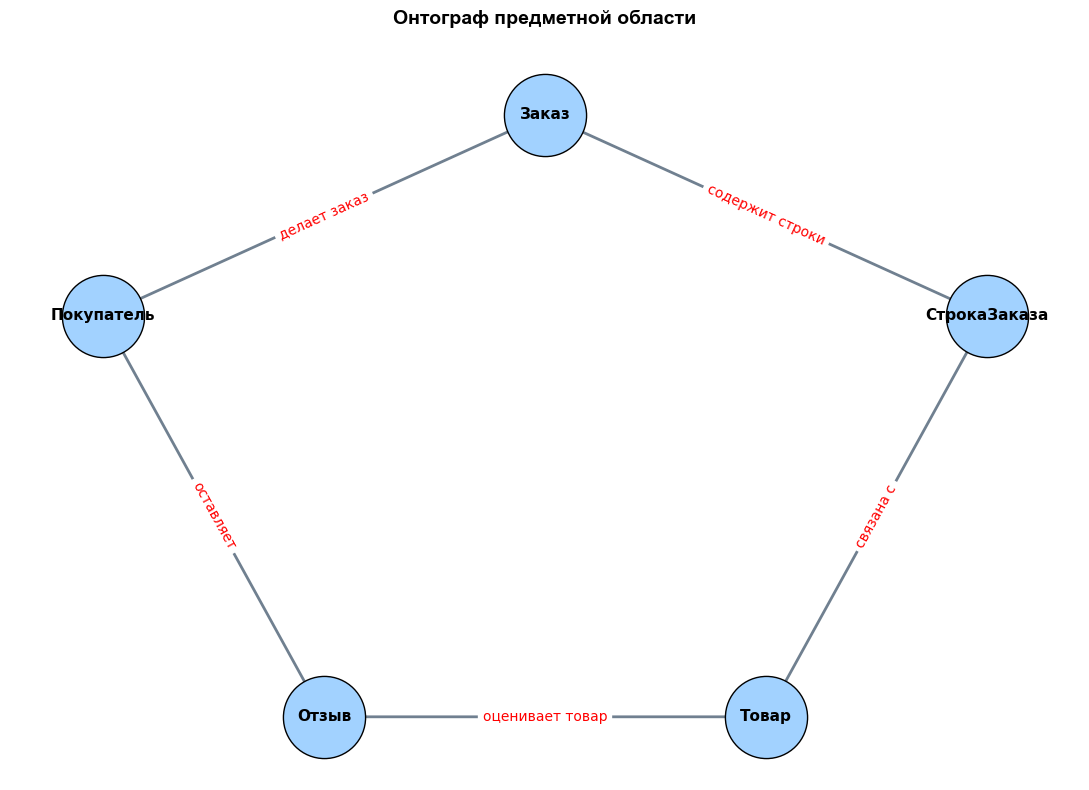

In [13]:
# Установка библиотек networkx (для расчетов графов и сетей) и matplotlib (для рисования графиков и картинок)
%pip install networkx matplotlib

# Импортируем networkx под коротким псевдонимом nx
import networkx as nx
# Импортируем модуль pyplot из matplotlib под псевдонимом plt для управления холстом и рисованием
import matplotlib.pyplot as plt

# Инициализируем пустой направленный граф (Directed Graph). 
# Слово DiGraph означает, что у наших связей (ребер) будут четкие стрелочки-направления: от кого к кому.
G = nx.DiGraph()

# Создаем список с названиями вершин нашего графа — это 5 главных классов
nodes = ["Покупатель", "Заказ", "СтрокаЗаказа", "Товар", "Отзыв"]
# Загружаем весь этот список вершин в наш граф G одной командой
G.add_nodes_from(nodes)

# Создаем список связей (ребер). Каждая связь — это тройка: (Откуда стрелка, Куда стрелка, Что написано на стрелке)
edges = [
    ("Покупатель", "Заказ", "делает заказ"),
    ("Заказ", "СтрокаЗаказа", "содержит строки"),
    ("СтрокаЗаказа", "Товар", "связана с"),
    ("Покупатель", "Отзыв", "оставляет"),
    ("Отзыв", "Товар", "оценивает товар")
]

# Проходимся циклом по каждой тройке из списка связей
for u, v, label in edges:
    # Добавляем связь в граф: u — начало, v — конец, а в параметр 'label' прячем текстовое описание связи
    G.add_edge(u, v, label=label)

# Задаем фиксированные координаты (X, Y) для каждой вершины на плоскости. 
# Это нужно, чтобы кружочки не слиплись в кучу, а красиво и симметрично распределились по экрану.
pos = {
    "Покупатель": (1, 3),
    "Заказ": (3, 4),
    "СтрокаЗаказа": (5, 3),
    "Товар": (4, 1),
    "Отзыв": (2, 1)
}

# Создаем "холст" (фигуру) для рисования размером 10 на 7 дюймов
plt.figure(figsize=(11, 8))

# Настраиваем шрифт 'Arial'. Это критически важно, чтобы Matplotlib не рисовал "квадратики" вместо русских букв.
plt.rcParams['font.family'] = 'Arial'

# Рисуем сами кружочки (узлы) на холсте согласно заданным координатам (pos).
# node_size задает размер кружка, node_color — приятный голубой цвет, edgecolors — черный контур вокруг них.
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#a2d2ff', edgecolors='black')

# Пишем текст (названия классов) прямо внутри наших нарисованных кружочков.
# Задаем размер шрифта 11 и делаем его жирным (bold).
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

# Рисуем линии со стрелочками (ребра графа). 
# arrowstyle определяет вид стрелки, width — толщину линии, а color — серый цвет.
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='#708090', width=2)

# Вытаскиваем из графа все спрятанные текстовые описания связей (параметры 'label'), которые мы добавляли в цикле
edge_labels = nx.get_edge_attributes(G, 'label')

# Рисуем эти текстовые подписи прямо поверх стрелочек. 
# Делаем шрифт размером 10 и красим его в контрастный красный цвет (red), чтобы связи бросались в глаза.
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='red')

# Добавляем красивый и жирный заголовок в самом верху нашего рисунка. Отступ pad=20 отодвигает его чуть выше от графа.
plt.title("Онтограф предметной области", fontsize=14, fontweight='bold', pad=20)

# Отключаем отображение осей координат (сетка с делениями X и Y тут не нужна, это ведь схема, а не математический график)
plt.axis('off')

# Автоматически подгоняем поля, чтобы все элементы и подписи влезли в границы картинки и ничего не обрезалось
plt.tight_layout()

# Финальная команда: выводим готовую графическую картинку онтографа на экран в Jupyter
plt.show()

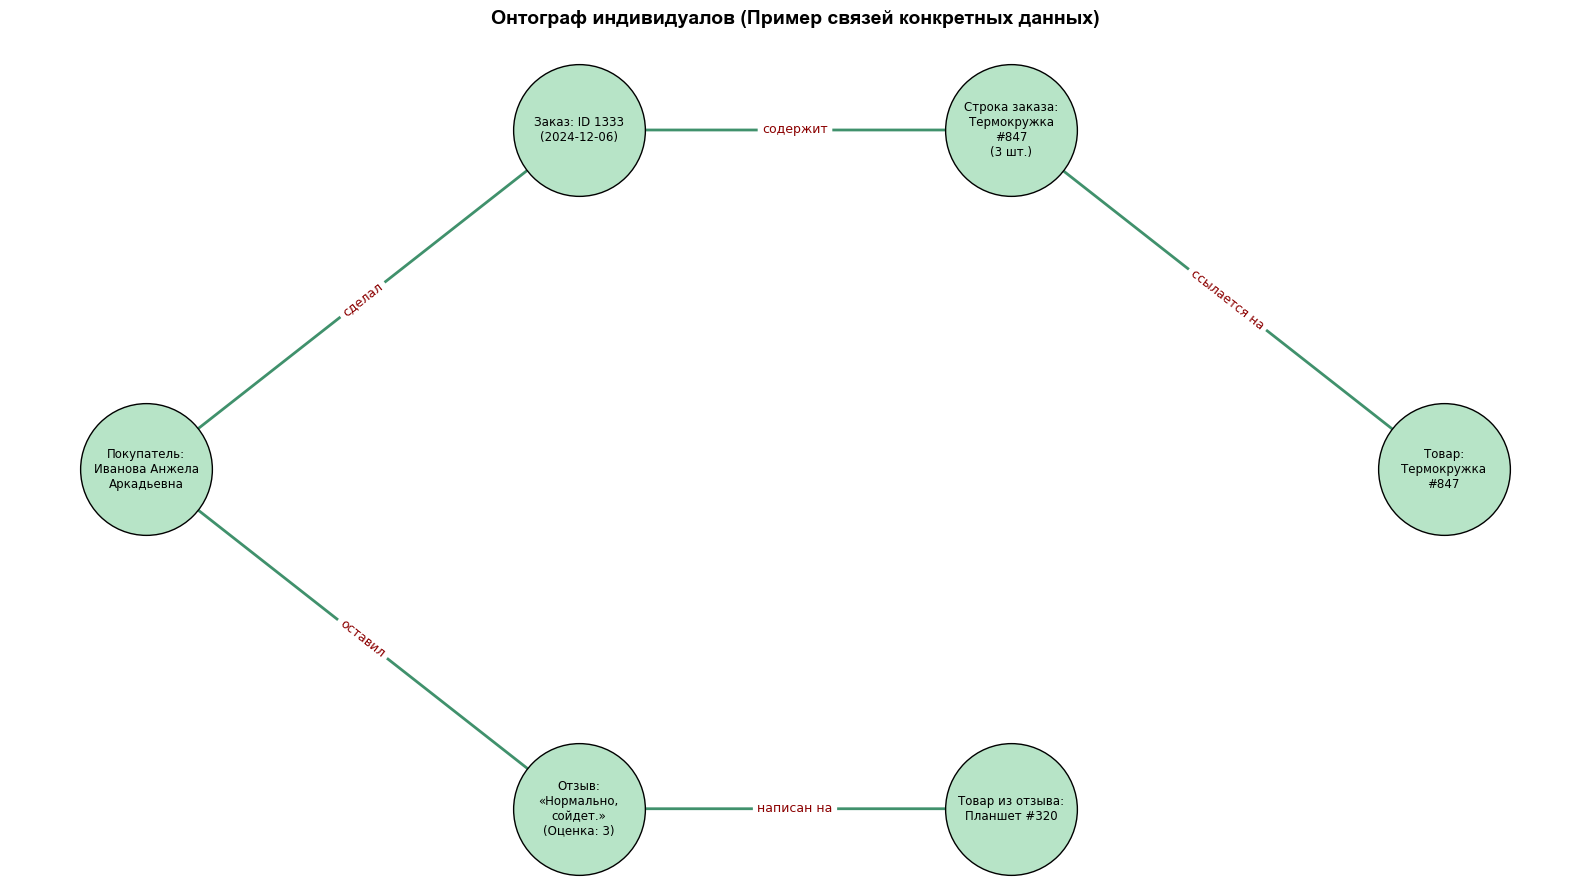

In [4]:
# Импортируем pandas для чтения ранее сохраненных CSV-файлов
import pandas as pd
# Импортируем networkx для создания сетевой структуры графа индивидуалов
import networkx as nx
# Импортируем matplotlib для отрисовки графики
import matplotlib.pyplot as plt
# Импортируем стандартный модуль textwrap для красивого форматирования длинных строк
import textwrap

# Специальная функция, которая разбивает длинные строки (например, ФИО или текст отзыва)
# на строки покороче (максимум по 15 символов), чтобы текст аккуратно помещался внутри кружков графа
def wrap_text(text, width=15):
    return '\n'.join(textwrap.wrap(str(text), width=width))

# --- ЗАГРУЗКА ДАННЫХ ИЗ CSV-ФАЙЛОВ ---
customers_df = pd.read_csv('customers.csv')
orders_df = pd.read_csv('orders.csv')
order_items_df = pd.read_csv('order_items.csv')
products_df = pd.read_csv('products.csv')
reviews_df = pd.read_csv('reviews.csv')

# --- СБОР ИНФОРМАЦИИ ДЛЯ ПЕРВОГО СЛУЧАЙНОГО КЛИЕНТА ---
# Вытаскиваем самую первую строчку (индекс 0) из таблицы покупателей
target_customer = customers_df.iloc[10]
c_id = target_customer['customer_id']  # Запоминаем ID этого покупателя
c_name = wrap_text(target_customer['full_name'])  # Берем его ФИО и сразу форматируем переносами строк

# Фильтруем таблицу заказов: ищем все заказы, которые сделал этот конкретный покупатель
cust_orders = orders_df[orders_df['customer_id'] == c_id]

# Проверяем, сделал ли этот покупатель хотя бы один заказ
if len(cust_orders) > 0:
    target_order = cust_orders.iloc[0]  # Берем самый первый заказ этого человека
    o_id = target_order['order_id']      # Запоминаем ID заказа
    o_date = target_order['order_date']  # Запоминаем дату заказа
    
    # Ищем строки (содержимое) этого конкретного заказа в таблице order_items
    order_items = order_items_df[order_items_df['order_id'] == o_id]
    target_item = order_items.iloc[0]    # Берем первый товар из этого заказа
    p_id = target_item['product_id']     # Запоминаем ID товара
    
    # Находим этот товар в общей таблице товаров, чтобы узнать его человеческое название
    target_product = products_df[products_df['product_id'] == p_id].iloc[0]
    p_name = wrap_text(target_product['name'])  # Название товара форматируем с переносами строк
    qty = int(target_item['quantity'])          # Запоминаем, сколько штук было куплено
else:
    # Запасной технический вариант на случай, если у первого покупателя вдруг не оказалось заказов
    o_id, o_date, p_name, qty = "1", "2026-05-12", "Товар", 1

# Фильтруем таблицу отзывов: ищем отзывы, оставленные этим же покупателем
cust_reviews = reviews_df[reviews_df['customer_id'] == c_id]

# Проверяем, написал ли этот человек хоть один отзыв
if len(cust_reviews) > 0:
    target_review = cust_reviews.iloc[0]  # Берем его первый отзыв
    # Форматируем текст отзыва: берем его в кавычки «» и в скобках дописываем поставленную оценку
    r_text = wrap_text(f"«{target_review['text']}» (Оценка: {target_review['rating']})")
    rev_p_id = target_review['product_id']  # Запоминаем ID товара, на который был написан этот отзыв
    # Находим название товара, который оценивали в отзыве
    rev_p_name = wrap_text(products_df[products_df['product_id'] == rev_p_id].iloc[0]['name'])
else:
    # Запасной вариант, если этот клиент не оставлял отзывов
    r_text, rev_p_name = "Отлично!", p_name

# --- ПОСТРОЕНИЕ СЕТЕВОГО ГРАФА ИНДИВИДУАЛОВ ---
# Создаем новый пустой направленный граф
G_ind = nx.DiGraph()

# Формируем итоговые текстовые блоки, которые будут написаны внутри каждого кружка.
# Используем f-строки, чтобы объединить тип сущности и реальные данные из таблиц (имена, даты, тексты)
node_cust = f"Покупатель:\n{c_name}"
node_order = f"Заказ: ID {o_id}\n({o_date})"
node_item = f"Строка заказа:\n{p_name}\n({qty} шт.)"
node_prod = f"Товар:\n{p_name}"
node_review = f"Отзыв:\n{r_text}"
node_rev_prod = f"Товар из отзыва:\n{rev_p_name}"

# Строим связи между узлами (создаем ребра графа и подписываем действия)
G_ind.add_edge(node_cust, node_order, label="сделал")
G_ind.add_edge(node_order, node_item, label="содержит")
G_ind.add_edge(node_item, node_prod, label="ссылается на")
G_ind.add_edge(node_cust, node_review, label="оставил")
G_ind.add_edge(node_review, node_rev_prod, label="написан на")

# Задаем жесткие координаты (X, Y) для каждого кружка на плоскости.
# Координаты раздвинуты широко (значения до 8.5), чтобы большие зеленые круги с текстом не налезали друг на друга.
pos_ind = {
    node_cust: (1, 3),
    node_order: (3.5, 4.2),
    node_item: (6, 4.2),
    node_prod: (8.5, 3),
    node_review: (3.5, 1.8),
    node_rev_prod: (6, 1.8)
}

# Создаем увеличенный холст для рисунка (размер 14 на 8 дюймов), чтобы поместились все детали
plt.figure(figsize=(16, 9))
# Настраиваем шрифт Arial для поддержки кириллицы
plt.rcParams['font.family'] = 'Arial'

# Рисуем узлы графа. Делаем круги огромными (node_size=9000) и красим в приятный пастельно-зеленый цвет (#b7e4c7)
nx.draw_networkx_nodes(G_ind, pos_ind, node_size=9000, node_color='#b7e4c7', edgecolors='black')

# Печатаем текст внутри зеленых кругов. Ставим аккуратный мелкий шрифт (font_size=8.5), чтобы слова не вылезали за края
nx.draw_networkx_labels(G_ind, pos_ind, font_size=8.5, font_weight='normal')

# Рисуем соединительные стрелки темно-зеленого цвета (#40916c) толщиной в 2 пикселя
nx.draw_networkx_edges(G_ind, pos_ind, arrowstyle='->', arrowsize=20, edge_color='#40916c', width=2)

# Извлекаем текстовые маркеры связей ("сделал", "содержит", "оставил"...)
edge_labels = nx.get_edge_attributes(G_ind, 'label')
# Рисуем эти подписи отношений прямо на стрелках темно-красным цветом (darkred) шрифтом 9-го размера
nx.draw_networkx_edge_labels(G_ind, pos_ind, edge_labels=edge_labels, font_size=9, font_color='darkred')

# Добавляем крупный жирный заголовок графика с отступом сверху (pad=25)
plt.title("Онтограф индивидуалов (Пример связей конкретных данных)", fontsize=14, fontweight='bold', pad=25)

# Скрываем координатную сетку, так как она не несет смысловой нагрузки для схемы отношений
plt.axis('off')

# Оптимизируем свободное пространство на картинке, убирая лишние пустые поля по краям
plt.tight_layout()

# Финальный аккорд: выводим готовую схему с реальными данными на экран в Jupyter Notebook
plt.show()

In [22]:
#Поскольку объём заказов (3000) превышает число покупателей (500), в среднем на одного клиента приходится по 6 заказов.
#В блоке генерации отзывов покупатели и товары связывались случайным образом из общих списков. 
#Поэтому на графе индивидуалов мы видим вполне жизненную ситуацию: покупатель в текущем заказе приобретает один товар ("Исполнять"), 
#а отзыв пишет на другой товар ("Плясать"), который он мог приобрести в одном из своих прошлых заказов